# Group Project - Prediction of Penguin Species

## 1. Authorship

- Yi-Chong Jiang

 *06/02/2022*

## 2. Data import and cleaning

In [68]:
# standard import
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import tree, preprocessing
import numpy as np
import seaborn as sns

In [70]:
# get the data from the website and store it as a variable
url = "https://philchodrow.github.io/PIC16A/datasets/palmer_penguins.csv"
penguins = pd.read_csv('palmer_penguins.csv')
# shorten the species name
penguins["Species"] = penguins["Species"].str.split().str.get(0)
# remove intuitively irrelevant columns
penguins = penguins.drop(labels = ["studyName", "Sample Number",'Region', 'Stage', 'Individual ID', 'Clutch Completion', 'Date Egg', 'Comments'], axis = 1)

In [71]:
# drop the rows with na values and assign back to the dataset
penguins = penguins.dropna()
# make sure we have the same random number every time
np.random.seed(3354354524)
# separate dataset for model (without encoded labels)
m_penguins = penguins.copy()

In [72]:
le = preprocessing.LabelEncoder()
# encode sex and species as integers
m_penguins['Sex'] = le.fit_transform(m_penguins['Sex'])
m_penguins['Species'] = le.fit_transform(m_penguins['Species'])
m_penguins['Island'] = le.fit_transform(m_penguins["Island"])

Now if we take a look at the two datasets we've created, the only difference is that one of them has the categorical data encoded to numbers and one is kept the same. We will use the latter one for EDA graphs so that we can have clearer labels.

In [73]:
m_penguins.head()

,Species,Island,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
1,0,2,39.5,17.4,186.0,3800.0,1,8.94956,-24.69454
2,0,2,40.3,18.0,195.0,3250.0,1,8.36821,-25.33302
4,0,2,36.7,19.3,193.0,3450.0,1,8.76651,-25.32426
5,0,2,39.3,20.6,190.0,3650.0,2,8.66496,-25.29805
6,0,2,38.9,17.8,181.0,3625.0,1,9.18718,-25.21799


In [74]:
penguins.head()

,Species,Island,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE,8.66496,-25.29805
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE,9.18718,-25.21799


## 3. Exploratory Analysis
Now we begin our exploratory analysis.

*First*, we can check the variances of each continuous variable and have a basic idea of which ones we may eliminate in our modeling.

In [75]:
m_penguins[["Culmen Length (mm)", "Culmen Depth (mm)", "Flipper Length (mm)",
            "Body Mass (g)", "Delta 15 N (o/oo)", "Delta 13 C (o/oo)"]].var()

Culmen Length (mm)         29.945263
Culmen Depth (mm)           3.864929
Flipper Length (mm)       195.010009
Body Mass (g)          654253.240741
Delta 15 N (o/oo)           0.305346
Delta 13 C (o/oo)           0.624255
dtype: float64

From the table above, we see that the columns `Delta 15 N (o/oo)` and `Delta 13 C (o/oo)` have very small variance across all samples; therefore, they have very little influence on the estimation of species as a whole, so we may drop them.

In [76]:
m_penguins = m_penguins.drop(["Delta 15 N (o/oo)", "Delta 13 C (o/oo)"], axis = 1)

Then we check for potential imbalance in the dataset via a histogram of species counts:

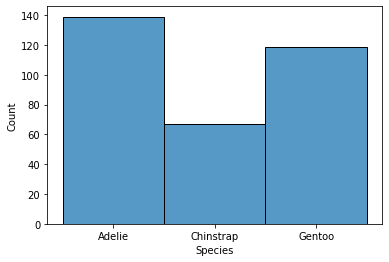

In [78]:
fgrid = sns.histplot(data = penguins, x = "Species")

The histogram above indicates that there is an imbalance of counts across the species. The basic idea is guessing the species to be "Adelie" has better chances to be correct, so there might be a tendency in our model to yield "Adelie" as a result. Whether this should occur is unknown, but we may note this if error should occur.

Next, we explore the combination of island, culmen length, and culmen depth. The scatterplot below has very clear division between different colors, so we know that our data is easily separable, and the combination of `["Island", "Culmen Length", "Culmen Depth"]` seems pretty good.

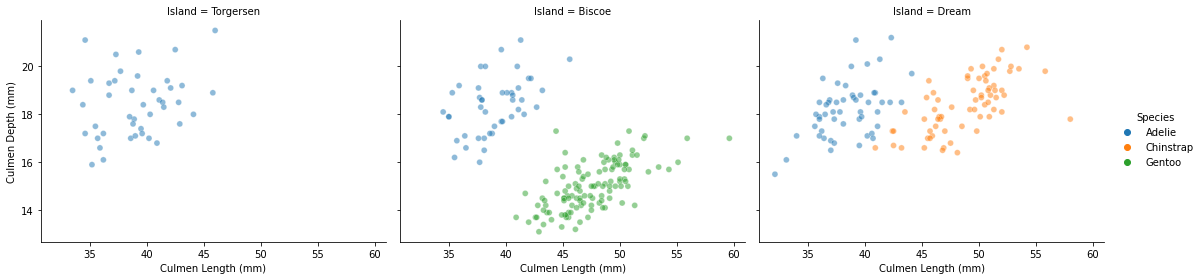

In [79]:
# graph of culmen length vs. depth of each species on each island
fgrid=sns.relplot(data = penguins, x = "Culmen Length (mm)", y = "Culmen Depth (mm)", 
                  hue = "Species", col = "Island", sizes = (40, 40), height = 4, 
                  aspect = 1.3, alpha = 0.5)

The table below can be a numerical summarization of the graph above, we can see the clear difference among measurements of individual species in each island.

In [80]:
penguins.groupby(["Species", "Island"])["Culmen Length (mm)", "Culmen Depth (mm)", "Flipper Length (mm)"].mean()

C:\Users\tinat\AppData\Local\Temp/ipykernel_11500/2796706063.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  penguins.groupby(["Species", "Island"])["Culmen Length (mm)", "Culmen Depth (mm)", "Flipper Length (mm)"].mean()


Culmen Length (mm)  Culmen Depth (mm)  \
Species   Island                                             
Adelie    Biscoe              38.975000          18.370455   
          Dream               38.401923          18.205769   
          Torgersen           39.055814          18.416279   
Chinstrap Dream               48.788060          18.404478   
Gentoo    Biscoe              47.544538          15.000000   

                     Flipper Length (mm)  
Species   Island                          
Adelie    Biscoe              188.795455  
          Dream               190.096154  
          Torgersen           192.162791  
Chinstrap Dream               195.671642  
Gentoo    Biscoe              217.193277

*Next*, we take a look at the distributions of each species grouped by `'Island'`, `'Body Mass (g)'`, and `'Sex'` respectively using histograms.

""


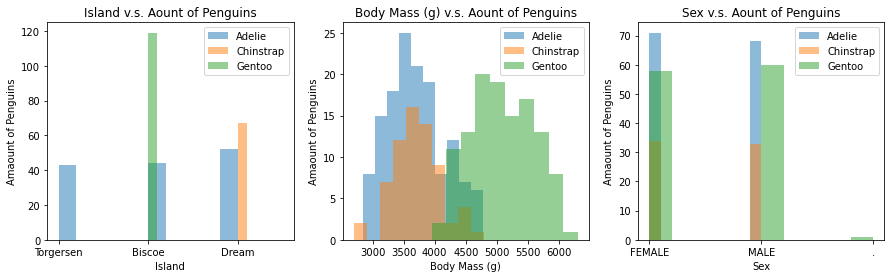

In [81]:
# create a plot with size (15, 4)
fig, ax = plt.subplots(1, 3, figsize = (15,4))

def histogram(df, columns):
    '''
    Plot the histograms for the specific columns from the dataframe given

    Parameter:
    ---------------
    df: the data frame given
    columns: the columns given to be plotted into each subplot

    Return:
    ---------------
    return nothing
    '''
    
    # loop through the index of the columns given
    for i in range(len(columns)):
        # loop throught the set of all possible species to make legend labels
        for j in set(df['Species']):
            ax[i].hist(df[columns[i]], alpha = 0.5, label = j)

        # make and show the graph titles and axes labels
        ax[i].set(xlabel = columns[i], ylabel = 'Amaount of Penguins')
        ax[i].set_title(str(columns[i]) + ' v.s. Aount of Penguins')
        ax[i].legend()

# group the dataframe by species and apply the histogram function
penguins.groupby('Species').apply(histogram, ['Island', 'Body Mass (g)', 'Sex'])

- Notice that for the first graph for the distibution of each species over the three islands. We can see that Gentoo can only be found (only distibuted) on Biscoe island, and Chinstrap can only be found on Dream island. Also, Adelie seems to be more equally distributed throughout the three islands comparing to the other two species. 
- For the second graph, we can tell that one species tend to have a body mass within a specific range. To illustrate, Gentoo has a general higher body mass (around 4200-6300 grams) than the other species. Therefore, we might expect to find body mass as one of the predictor for species.
- For the last graph, we noticed that none of the sepceis have a fairly amount of difference between the proportion of females and males. Thus, using sex to predict the species seems to not be a good idea. 

## 4. Feature Selection
First, we separate the dataset into training set, validationset, and test set, with a ratio of 8:1:1.

In [82]:
# import train_test_split funtion to split the training and testing data
from sklearn.model_selection import train_test_split

# set y as the species column and X as all columns except species
X = m_penguins.drop("Species", axis = 1)
y = m_penguins.Species
# split the data using test_size = 0.2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2021)

To draw discrete regions, we want combinations with at least 1 categorical data.

In [83]:
# import combinations function to aid the function of finding possible columns
from itertools import combinations

# get the continuous variables
choices = X_train.columns
combinations = list(combinations(choices, 3))

Now we define a function to remove all the combinations with three continuous variables, just for the convenience of future graphing of decision regions.

In [84]:
def num_cont(l):
    '''
    Returns the number of continuous variables in the combination

    Parameters:
    -----------
    l: list, contains the variables

    Return:
    num: int, the number of continuous variables in the combination
    '''
    
    num = 0
    conts = X_train.drop(['Sex', 'Island'], axis = 1).columns
    for i in l:
        if i in conts:
            num = num + 1

    # return the number of continuous variables in the combination
    return num

Now we use the function above to remove the unfavarable combinations.

In [85]:
# initialize the cols as empty
cols = []

# loop through each possible combinations found above
for l in combinations:
    if num_cont(l) == 2:
        cols.append(list(l))

cols

[['Island', 'Culmen Length (mm)', 'Culmen Depth (mm)'],
 ['Island', 'Culmen Length (mm)', 'Flipper Length (mm)'],
 ['Island', 'Culmen Length (mm)', 'Body Mass (g)'],
 ['Island', 'Culmen Depth (mm)', 'Flipper Length (mm)'],
 ['Island', 'Culmen Depth (mm)', 'Body Mass (g)'],
 ['Island', 'Flipper Length (mm)', 'Body Mass (g)'],
 ['Culmen Length (mm)', 'Culmen Depth (mm)', 'Sex'],
 ['Culmen Length (mm)', 'Flipper Length (mm)', 'Sex'],
 ['Culmen Length (mm)', 'Body Mass (g)', 'Sex'],
 ['Culmen Depth (mm)', 'Flipper Length (mm)', 'Sex'],
 ['Culmen Depth (mm)', 'Body Mass (g)', 'Sex'],
 ['Flipper Length (mm)', 'Body Mass (g)', 'Sex']]

## 5. Modeling

Now we can start building models and see which combination and hyper parameter gives the best result for each model!

But before we start, do some preparation first:

We start by creating dictionaries of our labeled variables for sake of readability of labels.

In [86]:
# create dictionaries for the sake of labeling
islands = {0: "Biscoe", 1: "Dream", 2: "Torgerson"}
colors = {0: "red", 1: "green", 2: "blue"}
species = {0: "Adelie", 1: "Chinstrap", 2: "Gentoo"}
sexes = {0: ".", 1: "FEMALE", 2: "MALE"}

# combine training set as a whole in case we need them
train = pd.concat([X_train, y_train], axis = 1)

Then, we define a function that plots decision regions based on different discrete variables we may have and label them correctly and consistently.

In [87]:
# import ListedColormap and Patch functions to aid for regions plotting
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

def plot_regions(c,X,y,cat):
    '''
    Plots the decision region of a given ml model
    
    Parameters:
    -----------
    c: the machine learning model
    X, y: predictor and target
    cat: column name of the categorical data
    
    Output:
    -----------
    a plot of decision regions
    '''

    # fit the model to the whole set of data
    c.fit(X, y)
    # custom colormap
    colors = np.array(['red', 'blue', 'green'])
    colorsmap = ListedColormap(['red', 'blue', 'green'])

    # but plot for different categories
    for i in range(0, len(set(X_train[cat]))):
        # obtain corresponding subsets to predict using the fitted model
        X = X_train[X_train[cat] == i].drop(cat, axis = 1)
        y = y_train[X_train[cat] == i]
        x0 = X.iloc[:,0]
        name0 = x0.name
        x1 = X.iloc[:,1]
        name1 = x1.name
        grid_x = np.linspace(x0.min(), x0.max(), 501) 
        grid_y = np.linspace(x1.min(), x1.max(), 501) 

        xx,yy = np.meshgrid(grid_x, grid_y)
        np.shape(xx), np.shape(yy)

        XX = xx.ravel()
        YY = yy.ravel()

    #np.shape(np.c_[XX,YY])

        p = c.predict(np.c_[XX,YY])
    
        p = p.reshape(xx.shape)

    #plot the decision regions
        sc = ax[i].contourf(xx, yy, p, cmap = colorsmap, alpha = .2)

        ax[i].scatter(x0, x1, c = colors[y])
        bounds = np.linspace(0,3,4)
        # set labels for subplots according to the discrete variable in the combo
        if cat == "Island":
            ax[i].set(xlabel = name0, ylabel = name1, title = islands[i])
        else:
            ax[i].set(xlabel = name0, ylabel = name1, title = sexes[i])
    # plt.colorbar(sc, spacing='proportional',ticks=bounds)
    legend_elements = [Patch(facecolor = 'red', edgecolor = 'r',
                         label = 'Adelie', alpha = 0.5),
                       Patch(facecolor = 'blue', edgecolor = 'b',
                         label = 'Chinstrap', alpha = 0.5),
                       Patch(facecolor = 'green', edgecolor = 'g',
                         label = 'Gentoo', alpha = 0.5)]
    ax[2].legend(handles = legend_elements, bbox_to_anchor = (1,-0.1))

Now we can start with our modeling process!

In this project, we plan to use 3 Machine Learning Strategies:
- Random Forest
- Logistic Regression
- Support Vector Machine

### (a) Random Forrest

We are interested in finding the best `max_depth` and column combination for our Random Forrest model. To achieve such a goal, we use `GridSearchCV` to help us.

In [88]:
# import RandomForestClassifier and GridSearchCV functions
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# initialize the best score, best combo, and best max depth
best_score = 0
best_combo = []
best_md = 0

# loop through the index of each cols generated above
for i in range(len(cols)):
    F = RandomForestClassifier()
    # the dictionary stores the possible max_depth parameters from 1 to 29
    params = {"max_depth": (range(1,30))}
    grids = GridSearchCV(F, params, cv=5)
    grids.fit(X_train[cols[i]], y_train)
    x=grids.best_score_

    # update the 'best' data if the score found (x) is larger
    if x > best_score:
        best_score = x
        best_combo = cols[i]
        best_md = grids.best_params_

# print the best combo, best score, and best max_depth found
print("Best combo is:", best_combo)
print("Best score is:", best_score)
print("Best max_depth is:", best_md)

Best combo is: ['Island', 'Culmen Length (mm)', 'Culmen Depth (mm)']
Best score is: 0.9884615384615385
Best max_depth is: {'max_depth': 19}


Now that we have the best combination and best hyper parameter, we may begin plotting the decision region.

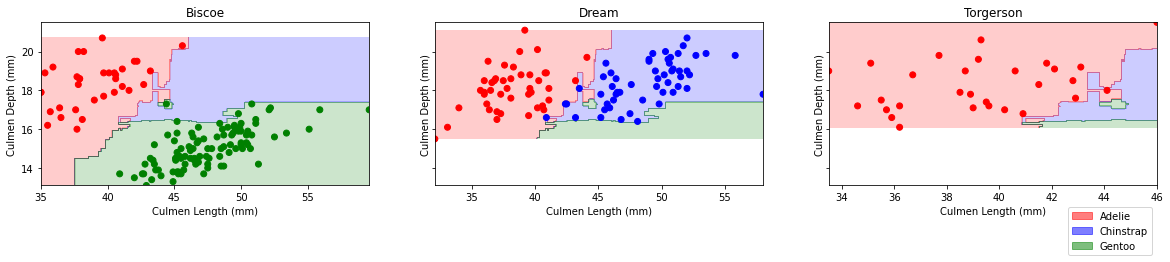

In [89]:
# creating new figures showing plot regions for each species
fig, ax = plt.subplots(1, 3, figsize = (20, 3), sharey = True)
# the best max_depth parameter found is 19
F = RandomForestClassifier(max_depth = 19)
# set the two continuous functions from the best combo as X
X = X_train[['Culmen Length (mm)', 'Culmen Depth (mm)']]
# plot the regions and pass the discrete function ('Island') as a parameter
plot_regions(F, X, y_train, "Island")

We can see different decision regions on each island with respect to Culmen Length vs. Culmen Depth. The red, blue and green regions are decision regions for Adelie, Chinstrap, and Gentoo penguins, respectively.

*Error Analysis*

There are some decision regions ended up mistakenly drawn. For instance, we can see that from the first graph, there exists a small region predicted within the blue (Chinstrap) region becasue there exisits a plot there. The similar situation happen for the rest two graphs that the map-like border of the decision regions are efffected by the distribution of plots. 

### (b) Logistic Regression

In [90]:
# import RandomForestClassifier and GridSearchCV functions
from sklearn.linear_model import LogisticRegression

# initialize the best score, best combo, and best penalty parameter
best_score = 0
best_combo = []
best_pn = ""

# loop through the index of each cols generated above
for i in range(len(cols)):
    LR = LogisticRegression(max_iter = 1000)
    # the dictionary stores the possible penalty parameters as either '12' or 'none'
    params = {"penalty" : ["l2", "none"]}
    grids = GridSearchCV(LR, params, cv = 5)
    grids.fit(X_train[cols[i]], y_train)
    x = grids.best_score_

    # update the 'best' data if the score found (x) is larger
    if x > best_score:
        best_score = x
        best_combo = cols[i]
        best_pn = grids.best_params_
        
# print the best combo, best score, and best penalty found
print("Best combo is:", best_combo)
print("Best score is:", best_score)
print("Best penalty is:", best_pn)

Best combo is: ['Island', 'Culmen Length (mm)', 'Culmen Depth (mm)']
Best score is: 0.9923076923076923
Best penalty is: {'penalty': 'none'}


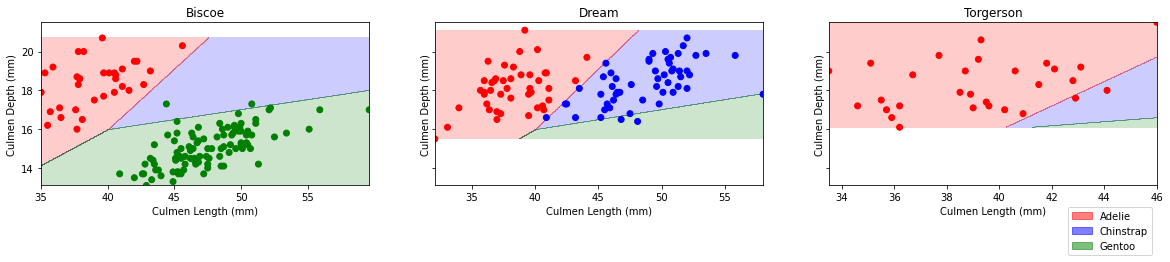

In [91]:
# creating new figures showing plot regions for each species
fig, ax = plt.subplots(1, 3, figsize = (20, 3), sharey = True)
# the best penalty parameter found is 'none'
LR = LogisticRegression(max_iter = 1000, penalty = 'none')
# set the two continuous functions from the best combo as X
X = X_train[['Culmen Length (mm)', 'Culmen Depth (mm)']]
# plot the regions and pass the discrete function ('Island') as a parameter
plot_regions(LR, X, y_train, "Island")

The legend and labels for this graph is the same as we did in Random Forest.

*Error Analysis*

For the Logistic regression model, The best performance on the training set is 99.23% accurate. In the decision region plot, we can see that there are some data points that fall into the wrong decision region: one Gentoo on Biscoe Island is mistaken as Chinstrap, two Chinstraps on Dream Island are mistakened as Gentoo, and two Adelies on Torgerson was mistakened as Chinstrap.

### (c) Support Vector Machine

In [92]:
# import Support Vector Machine module
from sklearn import svm

# initialize the best score, best combo, and best kernel
best_score = 0
best_combo = []
best_k = None

# loop through the index of each cols generated above
for i in range(len(cols)):
    SVM = svm.SVC()
    # the dictionary stores all possible kernel parameters
    params = {'kernel' : ['linear', 'poly', 'sigmoid', 'rbf']}
    grids = GridSearchCV(SVM, params, cv = 5)
    grids.fit(X_train[cols[i]], y_train)
    x = grids.best_score_

    # update the 'best' data if the score found (x) is larger
    if x > best_score:
        best_score = x
        best_combo = cols[i]
        best_k = grids.best_params_

# print the best score, best combo, and best kernel parameter found
print("Best combo is:", best_combo)
print("Best score is:", best_score)
print("Best kernel is:", best_k)

Best combo is: ['Island', 'Culmen Length (mm)', 'Culmen Depth (mm)']
Best score is: 0.9884615384615385
Best kernel is: {'kernel': 'linear'}


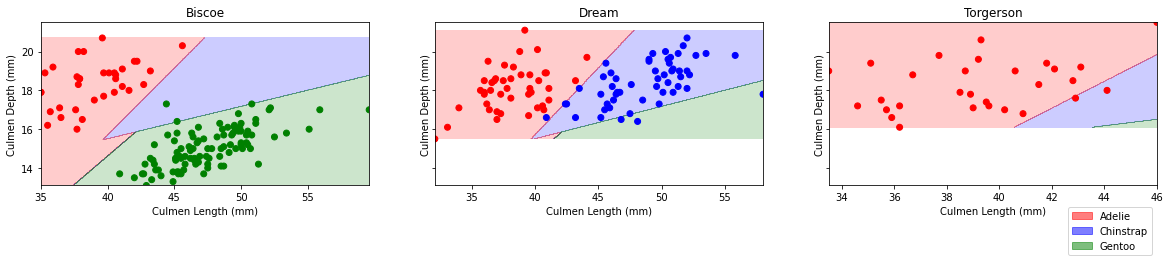

In [93]:
# creating new figures showing plot regions for each species
fig, ax = plt.subplots(1, 3, figsize = (20, 3), sharey = True)
# the best kernel parameter found is 'linear'
SVM = svm.SVC(kernel = 'linear')
# set the two continuous functions from the best combo as X
X = X_train[['Culmen Length (mm)', 'Culmen Depth (mm)']]
# plot the regions and pass the discrete function ('Island') as a parameter
plot_regions(SVM, X, y_train, 'Island')

*Error Analysis*

There are some plots has been mistakenly predicted in a wrong decision region. To illustrate, we can see that there's one Gentoo penguin being mistakenly plot into the Chinstrap area. The similar situation happen for the rest two graphs as well. We could see more than two plots of Chinstrap penguins being placed outside of Chinstrap's area, and there are also two plots of Adelie penguins being mistakenly placed into the Chinstrap's decision region. 

### (d) Analysis

Based on the `best_score` generated by the three model above, we noticed that the second logictic model has the highest best_score of 0.9923. Thus, we determined the Logistic Regression model as the best model among the three. 

We compare the cross validation score between our training set and testing set. Note that since we used `GridSearchCV` at construction, we should not have to worry about overfitting here. But still, we would like to know the performance on unseen test data.

In [94]:
# use 'none' as the penalty parameter in Logistic Regression model
LR = LogisticRegression(max_iter = 1000, penalty = 'none')
# fit training data into the LR model
best_combo = ['Island', 'Culmen Length (mm)', 'Culmen Depth (mm)']
LR.fit(X_train[best_combo], y_train)
# compare the accuracy on training and testing sets
LR.score(X_train[best_combo], y_train), LR.score(X_test[best_combo], y_test)

(1.0, 0.9846153846153847)

Now we have that the performance on training set is 100% accurate, while our test data has achieved around 98.5% accuracy. Hence our model is not overfit and has desired performance.

## 6. Discussion

Through data exploration at the beginning, we noticed that `Sex` barely have an affect on `Species`, but we could see `Species` is distributed in a predictable pattern among `Body Mass (g)` and `Island`(referring to the histograms drawn by using matplotlib functions). Furthermore, the distribution of `Species` can also be visually grouped according to the `Culmen Length (mm)`x`Culmen Depth (mm)` graphs (referring to the replot graph using the seaborn function). 

Then, we split the data into two parts with training data, having proportion of 0.8, and testing data, having proportion of 0.2. By using the three different models (*Random Forrest*, *Logistic Regression*, and *Suuport Vector Machine*), we tend to find the model that generates the highest score for the training data set. 

Based on our experiment, all of the three models found the same exact combo of predictors: `Island`, `Culmen Length (mm)`, and `Culment Depth (mm)`. Meaning that those three features are **perfectly selected** and could be the best predictors for `Species`. 

Also, we can see that the *Random Forrest* model generates the best score to be **0.9885**, the *Logistic Regression* model generates the best score to be **0.9923**, and the *Suuport Vector Machine* model generates the best score to be **0.9885**. Thus, we conclude that the *Logistic Regression* model, with the penalty parameter as *'none'*, could be the best model to predict the species of penguins because it has the highest best score. 

Lastly, we compared the fitting score generated by the training data set and the testing data set. The result was that the training set performs a **100%** of accuracy, and the testing set performs about **98.5%** of accuracy. This means that out model (*Logistic Regression*) does not overfit and meanwhile has a fairly accurate predictions for `Species`. 